# Лабораторна робота 7

## Завдання 1

Діедральна група $D_{20}$ має ряд нормальних підгруп: 

In [1]:
G = DihedralGroup(20)
[N.order() for N in G.normal_subgroups()]

[40, 20, 20, 20, 10, 4, 2, 5, 1]

Для кожної нормальної підгрупи $N$ побудуйте ендоморфізм $\phi : D_{20} \rightarrow D_{20}$ такий, що $Ker \phi = N$. Задайте його через `PermutationGroupMorphism` і використайте метод `.kernel` як підтвердження. 

___Зауваження___: ядро має бути не __ізоморфне__ підгрупі, а __рівне__ їй.

In [3]:
G = DihedralGroup(20)
normal_subgroups = [subgroup for subgroup in G.normal_subgroups()]

with open("endomorphisms.txt", "w") as file:
    phi_mappings = [
        [G('()'), G('()')],
        [G('()'), G('(1,20)(2,19)(3,18)(4,17)(5,16)(6,15)(7,14)(8,13)(9,12)(10,11)')],
        [G('(1,11)(2,12)(3,13)(4,14)(5,15)(6,16)(7,17)(8,18)(9,19)(10,20)'), G('()')],
        [G('(1,11)(2,12)(3,13)(4,14)(5,15)(6,16)(7,17)(8,18)(9,19)(10,20)'), G('(1,11)(2,12)(3,13)(4,14)(5,15)(6,16)(7,17)(8,18)(9,19)(10,20)')],
        [G('(1,3)(4,20)(5,19)(6,18)(7,17)(8,16)(9,15)(10,14)(11,13)'), G('(1,13)(2,12)(3,11)(4,10)(5,9)(6,8)(14,20)(15,19)(16,18)')],
        [G('(1,5,9,13,17)(2,6,10,14,18)(3,7,11,15,19)(4,8,12,16,20)'), G('(2,20)(3,19)(4,18)(5,17)(6,16)(7,15)(8,14)(9,13)(10,12)')],
        [G('(1,3,5,7,9,11,13,15,17,19)(2,4,6,8,10,12,14,16,18,20)'), G('(2,20)(3,19)(4,18)(5,17)(6,16)(7,15)(8,14)(9,13)(10,12)')],
        [G('(1,6,11,16)(2,7,12,17)(3,8,13,18)(4,9,14,19)(5,10,15,20)'), G('(2,20)(3,19)(4,18)(5,17)(6,16)(7,15)(8,14)(9,13)(10,12)')],
        [G('(1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20)'), G.gens()[1]]
    ]

    for index, mapping in enumerate(phi_mappings, start=1):
        phi = PermutationGroupMorphism(G, G, mapping)
        kernel = phi.kernel()
        is_correct = kernel == normal_subgroups[index - 1]

        print(f"{index}. {phi}", file=file)
        print(f"   Kernel: {kernel}, Order: {kernel.order()}, Correctness: {is_correct}", file=file)
        print("\n", file=file)


IOStream.flush timed out
IOStream.flush timed out


## Завдання 2

Знайдіть центр та представників класів спряженості для груп $C_{11}, D_{13}, Q_{8}, SL(3, \mathbb{Z}_7)$. Виведіть кількість елементів в кожній групі, кількість класів спряженості та запишіть формулу для них. 

In [4]:
groups = {
    "C11": CyclicPermutationGroup(11),
    "D13": DihedralGroup(13),
    "Q8": QuaternionGroup(),
    "SL(3, Z7)": SL(3, GF(7))
}

with open("groups.txt", "w") as output_file:
    for name, group_instance in groups.items():
        group_center = group_instance.center()
        classes = group_instance.conjugacy_classes()
        class_representatives = [cls.representative() for cls in classes]

        print(f"Group: {name}", file=output_file)
        print(f"  Group order: {group_instance.order()}", file=output_file)
        print(f"  Number of conjugacy classes: {len(classes)}", file=output_file)
        print(f"  Center of the group: {group_center}, order = {group_center.order()}", file=output_file)
        print("  Representatives of the conjugacy classes:", file=output_file)
        for index, representative in enumerate(class_representatives, start=1):
            print(f"    Class {index}: {representative}", file=output_file)
        print("\n", file=output_file)


## Завдання 3

1. Побудуйте граф гіперкуба $C_4$ і знайдіть його групу автоморфізмів. Розгляньте цю групу і її дію на граф. Покажіть орбіти цієї групової дії та зробіть висновки. 
2. Знайдіть стабілізатор довільної вершини та розгляньте його як групу з дією на весь граф. Знайдіть орбіти цієї нової групової дії. Зробіть висновки в термінах гіперкуба.

Hypercube graph C4:


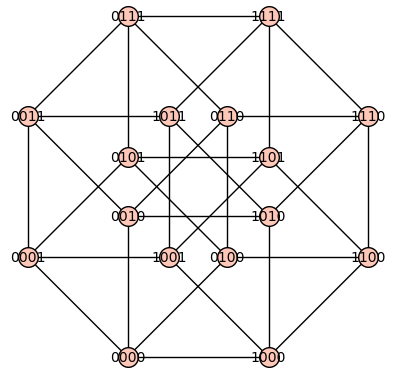

Automorphism group of C4 (order: 384):
Permutation Group with generators [('0001','1101')('1100','0000')('0011','1111')('1110','0010'), ('0001','1000')('1010','0011')('1100','0101')('1110','0111'), ('0001','0111')('1000','1110')('0110','0000')('1111','1001'), ('0100','0001','1101','0111')('1100','0011')('1000','1011','1110','0010')('0110','0000','1001','1111'), ('0100','1010')('0001','0011')('1100','1110')('1101','1111')('1000','0110')('0000','0010')('1011','0101')('1001','0111')]
Selected vertex: 0000
Stabilizer of vertex 0000 (order: 24):
Subgroup generated by [('0001','1000')('1010','0011')('1100','0101')('1110','0111'), ('0100','1000')('1010','0110')('1011','0111')('0101','1001'), ('0100','0010')('1010','1100')('0011','0101')('1101','1011')] of (Permutation Group with generators [('0001','1101')('1100','0000')('0011','1111')('1110','0010'), ('0001','1000')('1010','0011')('1100','0101')('1110','0111'), ('0001','0111')('1000','1110')('0110','0000')('1111','1001'), ('0100','0001','110

In [5]:
hypercube_graph = graphs.CubeGraph(4)
print("Hypercube graph C4:")
show(hypercube_graph)

aut_group = hypercube_graph.automorphism_group()
print(f"Automorphism group of C4 (order: {aut_group.order()}):")
print(aut_group)

chosen_vertex = hypercube_graph.vertices()[0]  # Наприклад, (0, 0, 0, 0)
print(f"Selected vertex: {chosen_vertex}")

vertex_stabilizer = aut_group.stabilizer(chosen_vertex)
print(f"Stabilizer of vertex {chosen_vertex} (order: {vertex_stabilizer.order()}):")
print(vertex_stabilizer)

stabilizer_orbits = vertex_stabilizer.orbits()
print(f"Orbits of the stabilizer acting on vertices of the graph: {stabilizer_orbits}")

aut_group_orbits = aut_group.orbits()
print(f"Orbits of the automorphism group acting on the vertices: {aut_group_orbits}")


## Завдання 4

1. Знайдіть прості графи з найменшою к-тю вершин, в яких групи автоморфізмів ізоморфні $A_2$ і $A_3$ відповідно. 
2. (додаткова) Зробіть те саме для $A_4$ i $A_5$. 

## Завдання 5

Побудуйте простий граф, в якого група автоморфізмів тривіальна. 

Граф з тривіальною групою автоморфізмів:


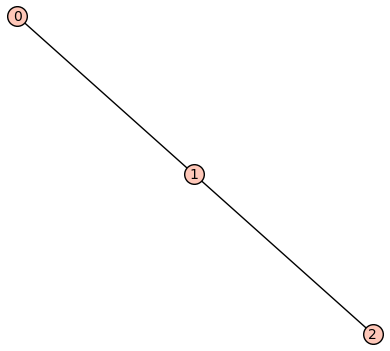

Група автоморфізмів графа (порядок: 2):
Permutation Group with generators [(0,2)]
Група автоморфізмів не є тривіальною.


In [6]:
# Створення простого графа з тривіальною групою автоморфізмів
G = Graph([(0, 1), (1, 2)])  # Граф-шлях із трьох вершин

print("Граф з тривіальною групою автоморфізмів:")
show(G)

# Отримання групи автоморфізмів графа
automorphism_group = G.automorphism_group()
print(f"Група автоморфізмів графа (порядок: {automorphism_group.order()}):")
print(automorphism_group)

# Перевірка на тривіальність групи
if automorphism_group.order() == 1:
    print("Група автоморфізмів є тривіальною.")
else:
    print("Група автоморфізмів не є тривіальною.")


## Завдання 6

1. Побудуйте граф, як показано в коді нижче, і знайдіть його групу автоморфізмів. Розгляньте цю групу і її дію на граф. Покажіть орбіти цієї групової дії та зробіть висновки. 
2. Знайдіть стабілізатор довільної вершини та розгляньте його як групу з дією на весь граф. Знайдіть орбіти цієї нової групової дії. Зробіть висновки в термінах графа.

_Підказка_: намалюйте граф як планарний за допомогою `.plot(layout='planar')` для кращої наочності.

Побудований граф:


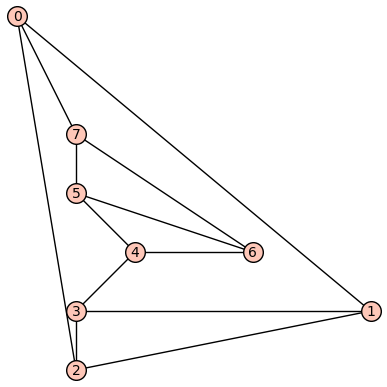

Група автоморфізмів графа (порядок: 16):
Permutation Group with generators [(5,6), (1,2), (0,3)(4,7), (0,4)(1,5)(2,6)(3,7)]
Орбіти дії групи автоморфізмів на вершинах графа: [[0, 3, 4, 7], [1, 2, 5, 6]]
Стабілізатор вершини 0 (порядок: 4):
Subgroup generated by [(5,6), (1,2)] of (Permutation Group with generators [(5,6), (1,2), (0,3)(4,7), (0,4)(1,5)(2,6)(3,7)])
Орбіти дії стабілізатора вершини 0 на вершинах графа: [[0], [1, 2], [3], [4], [5, 6], [7]]

Висновки:
1. Група автоморфізмів графа показує, як симетрії графа впливають на вершини.
2. Орбіти дії автоморфізмів дозволяють знайти еквівалентні вершини за симетрією.
3. Стабілізатор вершини визначає підгрупу автоморфізмів, які залишають цю вершину незмінною.
4. Орбіти стабілізатора дозволяють деталізувати симетрію графа у зв'язку з конкретною вершиною.


In [7]:
G = graphs.CycleGraph(8)
G.add_edges([(0, 2), (1, 3), (4, 6), (5, 7)])

print("Побудований граф:")
show(G.plot(layout="planar"))

automorphism_group = G.automorphism_group()
print(f"Група автоморфізмів графа (порядок: {automorphism_group.order()}):")
print(automorphism_group)

orbits = automorphism_group.orbits()
print(f"Орбіти дії групи автоморфізмів на вершинах графа: {orbits}")

vertex = 0
stabilizer = automorphism_group.stabilizer(vertex)
print(f"Стабілізатор вершини {vertex} (порядок: {stabilizer.order()}):")
print(stabilizer)

stabilizer_orbits = stabilizer.orbits()
print(f"Орбіти дії стабілізатора вершини {vertex} на вершинах графа: {stabilizer_orbits}")

print("\nВисновки:")
print("1. Група автоморфізмів графа показує, як симетрії графа впливають на вершини.")
print("2. Орбіти дії автоморфізмів дозволяють знайти еквівалентні вершини за симетрією.")
print("3. Стабілізатор вершини визначає підгрупу автоморфізмів, які залишають цю вершину незмінною.")
print("4. Орбіти стабілізатора дозволяють деталізувати симетрію графа у зв'язку з конкретною вершиною.")
